<a href="https://colab.research.google.com/github/HarithaGottumukkala/DATA266-1598_hw7/blob/main/DATA255_HW7_1598.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Step 0: Personal parameters and reproducibility

import random
import numpy as np
import torch

SID4 = 1598

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6

CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# Set random seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Reproducibility settings
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)
print("Device:", device)
print("PyTorch version:", torch.__version__)


SID4: 1598
SEED: 1598
SLICE: 598
HP_ID: 2
CLS_A: 8
CLS_B: 5
Device: cpu
PyTorch version: 2.11.0+cpu



## Question 1(a): Explain the fundamental architecture of a GAN, describing the roles of the generator and discriminator networks. How do these two components interact during training, and what is the theoretical goal of this adversarial process?

**Answer:**

A Generative Adversarial Network (GAN) consists of two neural networks called the **Generator (G)** and the **Discriminator (D)**. Both networks are trained together through a competitive process known as adversarial training.

The **Generator (G)** takes a random noise vector $z$ as input and produces a synthetic image $G(z)$. Its goal is to generate images that look realistic enough to fool the discriminator.

The **Discriminator (D)** receives both real images from the training dataset and fake images produced by the generator. It predicts whether an image is real or fake by assigning a probability between 0 and 1.

During training, the following process takes place:

1. The generator takes random noise and creates fake images.
2. The discriminator receives both real and generated images.
3. The discriminator updates its parameters to distinguish real images from fake ones.
4. The generator uses feedback from the discriminator to improve the quality of its generated images.
5. Both networks continue training through alternating updates.

The original GAN follows a minimax objective:

$$
\min_G \max_D V(D,G) =
\mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)]
+
\mathbb{E}_{z \sim p_z}[\log(1-D(G(z)))]
$$

Here, $x$ represents real data, $z$ represents random noise, $G(z)$ is the generated image, and $D$ predicts the probability that an image is real.

The discriminator tries to maximize this objective by correctly distinguishing real and fake images, while the generator tries to minimize it by producing more realistic images.

The **theoretical goal** is for the generator to learn the real-data distribution:

$$
p_g(x) = p_{\text{data}}(x)
$$

At the ideal equilibrium, the discriminator cannot distinguish real images from generated images and predicts:

$$
D(x) = 0.5
$$

For example, when a GAN is trained on clothing images, the generator initially produces unrealistic images. As training continues, it learns to generate images that increasingly resemble real clothing, making it harder for the discriminator to identify them as fake.



## Question 1(b): What is mode collapse in GANs? Explain why it occurs and discuss at least two techniques used to reduce or prevent it.

**Answer:**

**Mode collapse** is a common problem in GAN training where the generator produces only a limited variety of outputs instead of learning the complete distribution of the training data.

For example, if a GAN is trained on the FashionMNIST dataset containing shirts, shoes, bags, and other clothing items, the generator might repeatedly produce similar shoe images rather than generating different types of clothing. Even though these images may look realistic, the generator fails to capture the diversity of the dataset.

Mode collapse usually occurs because the generator finds a small set of outputs that can successfully fool the discriminator. Instead of learning different patterns in the dataset, it repeatedly generates similar samples. The changing feedback from the discriminator can also make GAN training unstable.

Two techniques that can help reduce mode collapse are:

**1. Minibatch Discrimination**

Minibatch discrimination allows the discriminator to compare multiple generated samples within the same batch rather than evaluating each image independently.

- It helps the discriminator recognize when the generator produces many similar images.
- If the generated images lack variety, the discriminator can use this information to identify them as fake.
- This encourages the generator to produce more diverse outputs to fool the discriminator.

For example, if the generator produces almost identical shoes in every batch, minibatch discrimination can detect this repetition and encourage the generator to learn different clothing patterns.

**2. Wasserstein GAN with Gradient Penalty (WGAN-GP)**

WGAN-GP improves GAN training by using a Wasserstein-based objective and a gradient penalty to stabilize the critic, which replaces the standard discriminator.

- It provides more useful training gradients when the generated and real-data distributions are very different.
- The gradient penalty encourages the critic to satisfy the smoothness constraint needed for Wasserstein training.
- More stable feedback helps the generator learn a wider variety of patterns instead of repeatedly producing similar images.

For example, rather than repeatedly generating one type of shoe, a generator trained using WGAN-GP may receive more informative feedback that helps it learn other clothing categories.

**Conclusion:**

Mode collapse reduces the diversity of images generated by a GAN. Minibatch discrimination helps detect repeated outputs, while WGAN-GP improves training stability and provides more useful gradients. Both techniques can reduce mode collapse, although neither guarantees that it will be completely eliminated.



## Question 1(c): Describe three different variants of GANs and explain the key innovations or improvements each introduces over the original GAN.

**Answer:**

Several variants of Generative Adversarial Networks (GANs) have been developed to improve image quality, training stability, and control over generated outputs. Three important variants are **Deep Convolutional GAN (DCGAN)**, **Conditional GAN (cGAN)**, and **CycleGAN**.

**1. Deep Convolutional GAN (DCGAN)**

DCGAN improves the original GAN by using convolutional neural networks instead of relying mainly on fully connected layers.

- It uses convolutional layers in the discriminator and transposed convolutional layers in the generator.
- These layers help the model learn spatial features such as shapes, textures, and patterns in images.
- It uses architectural techniques such as batch normalization to support more stable training.

**Example:** When trained on FashionMNIST, a DCGAN can learn visual patterns in clothing images and generate new images with similar shapes and textures.

**Key Improvement:** DCGAN introduces a convolution-based architecture that is better suited for image generation and often provides improved image quality and training stability.

**2. Conditional GAN (cGAN)**

A Conditional GAN extends the original GAN by adding extra information, such as a class label, to both the generator and discriminator.

- The generator receives random noise along with a condition, such as a clothing category.
- The discriminator checks whether the generated image looks realistic and matches the given condition.
- This allows us to control the type of image being generated.

**Example:** In FashionMNIST, we can provide the label "Sneaker" to generate sneaker images or the label "Bag" to generate bag images.

**Key Improvement:** Unlike the original GAN, which generates images without specifying a category, cGAN allows controlled generation based on user-provided conditions.

**3. Cycle-Consistent GAN (CycleGAN)**

CycleGAN is designed for image-to-image translation between two different domains without requiring paired training images.

- It uses two generators to translate images between domains A and B.
- It also uses two discriminators to distinguish real images from translated images in each domain.
- It introduces cycle-consistency loss, which encourages an image translated from A to B and back to A to resemble the original image.

The cycle-consistency relationship can be written as:

$$
G_{B \rightarrow A}(G_{A \rightarrow B}(x_A)) \approx x_A
$$

**Example:** CycleGAN can translate photographs into paintings and paintings into photo-like images without needing exact photo-painting pairs.

**Key Improvement:** CycleGAN enables unpaired image-to-image translation using cycle-consistency loss, which was not supported by the original GAN architecture.

**Conclusion:**

DCGAN improves image generation by introducing convolutional architectures, cGAN allows controlled image generation using additional conditions, and CycleGAN enables image translation between domains without paired datasets. These innovations make GANs useful for different image-generation tasks.



## Question 2: Train and Evaluate Autoencoders on FashionMNIST Using PyTorch

**Answer:**

In this experiment, I implement and evaluate two autoencoder architectures: a Fully Connected Autoencoder (FC-AE) and a Variational Autoencoder (VAE). Both models are trained using the FashionMNIST dataset.

The objective is to learn compressed representations of clothing images and reconstruct the original images from these representations. I will compare their reconstruction quality and training performance.

The FashionMNIST dataset contains 60,000 training images and 10,000 test images across 10 clothing categories. Each image is grayscale with a resolution of 28 × 28 pixels.

For preprocessing, I convert the images into PyTorch tensors and normalize their pixel values to the range [0, 1].


In [2]:

# Question 2: Load and prepare the FashionMNIST dataset

import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Convert images to tensors with pixel values between 0 and 1
transform = transforms.ToTensor()

# Download training data
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download test data
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    generator=torch.Generator().manual_seed(SEED)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# Class labels
class_names = train_dataset.classes

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Image shape:", train_dataset[0][0].shape)
print("Number of classes:", len(class_names))
print("Batch size:", batch_size)
print("Classes:", class_names)


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.07MB/s]

Training samples: 60000
Testing samples: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10
Batch size: 128
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


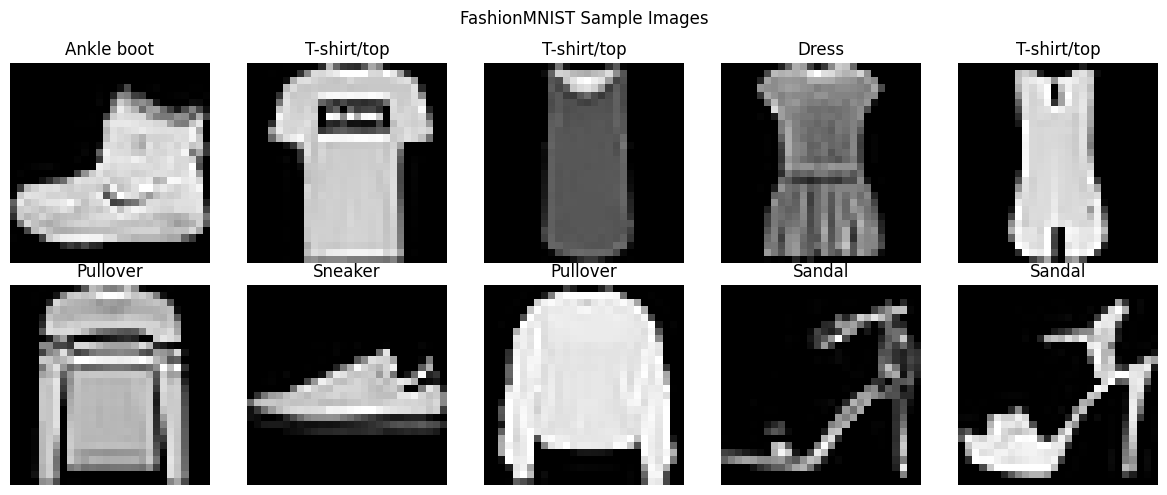

In [3]:

# Display sample FashionMNIST images

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle("FashionMNIST Sample Images")
plt.tight_layout()
plt.show()



### Question 2(a): Fully Connected Autoencoder (FC-AE)

**Answer:**

I implemented a Fully Connected Autoencoder (FC-AE) using PyTorch to reconstruct FashionMNIST images.

The model has two main components: an encoder and a decoder. The encoder compresses each 28 × 28 grayscale image into a smaller latent representation, while the decoder uses this compressed information to reconstruct the original image.

The input image is flattened into 784 pixel values and passed through fully connected layers of sizes 128 and 64, followed by a latent layer of size 32. The decoder gradually expands this representation back into 784 pixel values.

I used ReLU activation functions in the hidden layers and a Sigmoid activation in the output layer to keep the reconstructed pixel values between 0 and 1.


In [4]:

# Question 2(a): Fully Connected Autoencoder

import torch.nn as nn

class FullyConnectedAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # Encoder: compress the input image
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        # Decoder: reconstruct the original image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed


# Initialize the model
latent_dim = 32
fc_ae = FullyConnectedAE(latent_dim).to(device)

print(fc_ae)

# Count trainable parameters
total_params = sum(
    p.numel() for p in fc_ae.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", total_params)


FullyConnectedAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
    (6): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)

Trainable parameters: 222384


In [5]:

# Verify FC-AE input and output shapes

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images.to(device)

fc_ae.eval()

with torch.no_grad():
    reconstructed_images = fc_ae(sample_images)
    latent_vectors = fc_ae.encoder(sample_images)

print("Input shape:", sample_images.shape)
print("Latent shape:", latent_vectors.shape)
print("Reconstructed shape:", reconstructed_images.shape)

assert reconstructed_images.shape == sample_images.shape
assert latent_vectors.shape[1] == latent_dim

print("FC-AE architecture verification passed!")


Input shape: torch.Size([128, 1, 28, 28])
Latent shape: torch.Size([128, 32])
Reconstructed shape: torch.Size([128, 1, 28, 28])
FC-AE architecture verification passed!



### Question 2(a): FC-AE Training

**Answer:**

I trained the Fully Connected Autoencoder using the FashionMNIST training dataset. The model learns to reconstruct each input image by minimizing the difference between the original image and its reconstructed output.

I used **Mean Squared Error (MSE)** as the reconstruction loss because it measures the average squared difference between the original and reconstructed pixel values.

$$
L_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}(x_i-\hat{x}_i)^2
$$

Here, $x_i$ represents the original pixel value, $\hat{x}_i$ represents the reconstructed pixel value, and $N$ is the total number of pixel values.

For optimization, I used the **Adam optimizer** with a learning rate of 0.001. The model was configured to train for 15 epochs with a batch size of 128 and a latent dimension of 32.

I tracked both training loss and test-set reconstruction loss after each epoch to observe how the model improved. The test set was used for evaluation and did not contribute to parameter updates.


In [6]:

# Question 2(a): Train the Fully Connected Autoencoder

import time
import copy
import torch.optim as optim

# Training configuration
fc_epochs = 15
fc_learning_rate = 0.001

criterion = nn.MSELoss()
fc_optimizer = optim.Adam(
    fc_ae.parameters(),
    lr=fc_learning_rate
)

fc_train_losses = []
fc_test_losses = []

training_start = time.time()

for epoch in range(fc_epochs):

    # Training phase
    fc_ae.train()
    running_train_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        fc_optimizer.zero_grad()

        reconstructed = fc_ae(images)
        loss = criterion(reconstructed, images)

        loss.backward()
        fc_optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    avg_train_loss = running_train_loss / len(train_dataset)
    fc_train_losses.append(avg_train_loss)

    # Evaluation phase (no parameter updates)
    fc_ae.eval()
    running_test_loss = 0.0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            reconstructed = fc_ae(images)
            loss = criterion(reconstructed, images)

            running_test_loss += loss.item() * images.size(0)

    avg_test_loss = running_test_loss / len(test_dataset)
    fc_test_losses.append(avg_test_loss)

    print(
        f"Epoch {epoch + 1:02d}/{fc_epochs} | "
        f"Train MSE: {avg_train_loss:.6f} | "
        f"Test MSE: {avg_test_loss:.6f}"
    )

fc_training_time = time.time() - training_start

print("\nFC-AE training completed!")
print(f"Training time: {fc_training_time:.2f} seconds")
print(f"Final Train MSE: {fc_train_losses[-1]:.6f}")
print(f"Final Test MSE: {fc_test_losses[-1]:.6f}")

# Save trained model checkpoint
torch.save(
    {
        "model_state_dict": fc_ae.state_dict(),
        "optimizer_state_dict": fc_optimizer.state_dict(),
        "epochs": fc_epochs,
        "latent_dim": latent_dim,
        "seed": SEED,
        "train_losses": fc_train_losses,
        "test_losses": fc_test_losses
    },
    "fc_ae_checkpoint.pt"
)

print("Checkpoint saved: fc_ae_checkpoint.pt")


Epoch 01/15 | Train MSE: 0.044210 | Test MSE: 0.025872
Epoch 02/15 | Train MSE: 0.023357 | Test MSE: 0.021526
Epoch 03/15 | Train MSE: 0.020151 | Test MSE: 0.019197
Epoch 04/15 | Train MSE: 0.018594 | Test MSE: 0.017994
Epoch 05/15 | Train MSE: 0.017452 | Test MSE: 0.016980
Epoch 06/15 | Train MSE: 0.016583 | Test MSE: 0.016289
Epoch 07/15 | Train MSE: 0.015894 | Test MSE: 0.015679
Epoch 08/15 | Train MSE: 0.015267 | Test MSE: 0.015038
Epoch 09/15 | Train MSE: 0.014779 | Test MSE: 0.014687
Epoch 10/15 | Train MSE: 0.014403 | Test MSE: 0.014418
Epoch 11/15 | Train MSE: 0.014061 | Test MSE: 0.014014
Epoch 12/15 | Train MSE: 0.013775 | Test MSE: 0.013898
Epoch 13/15 | Train MSE: 0.013513 | Test MSE: 0.013460
Epoch 14/15 | Train MSE: 0.013302 | Test MSE: 0.013321
Epoch 15/15 | Train MSE: 0.013095 | Test MSE: 0.013123

FC-AE training completed!
Training time: 191.43 seconds
Final Train MSE: 0.013095
Final Test MSE: 0.013123
Checkpoint saved: fc_ae_checkpoint.pt


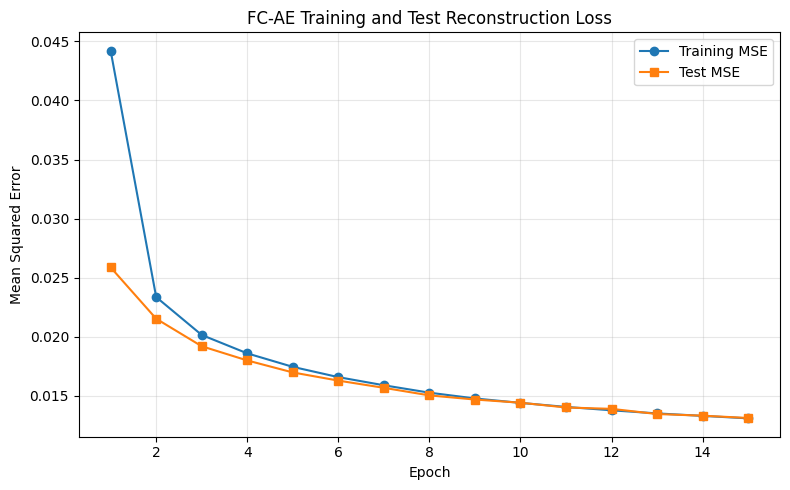

In [7]:

# Plot FC-AE training and test reconstruction loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, fc_epochs + 1),
    fc_train_losses,
    marker="o",
    label="Training MSE"
)

plt.plot(
    range(1, fc_epochs + 1),
    fc_test_losses,
    marker="s",
    label="Test MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("FC-AE Training and Test Reconstruction Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### FC-AE Training Results and Interpretation

**Answer:**

The Fully Connected Autoencoder was trained for 15 epochs using the FashionMNIST dataset. The training MSE decreased from 0.044210 in the first epoch to 0.013095 in the final epoch. Similarly, the test MSE decreased from 0.025872 to 0.013123.

The training took 191.43 seconds.

Both training and test loss decreased consistently throughout training, showing that the model gradually learned to reconstruct the input images more accurately. The final training and test losses were also very close, suggesting that the model generalized reasonably well to unseen images without obvious overfitting.

Overall, the loss curves indicate stable training. The next step is to compare the original and reconstructed images visually to understand how much image detail the model has learned to preserve.



### Question 2(b): Variational Autoencoder (VAE)

**Answer:**

I implemented a Variational Autoencoder (VAE) using PyTorch to reconstruct FashionMNIST images and learn a continuous latent representation.

Unlike a standard autoencoder, which maps each input image to a fixed latent vector, a VAE learns the mean ($\mu$) and log variance ($\log \sigma^2$) of a probability distribution. A latent vector is sampled from this distribution and passed through the decoder to reconstruct the input image.

The model uses fully connected layers for both the encoder and decoder, with a latent dimension of 32.

To allow gradients to flow through the sampling operation, I use the reparameterization trick:

$$
z = \mu + \sigma \odot \epsilon
$$

where $\epsilon \sim \mathcal{N}(0,I)$ and $\sigma = \exp(0.5 \log \sigma^2)$.

The VAE loss combines reconstruction loss and KL divergence:

$$
L_{\text{VAE}} = L_{\text{BCE}} + L_{\text{KL}}
$$

The reconstruction loss encourages the model to reproduce the original images, while KL divergence encourages the learned latent distribution to remain close to a standard normal distribution.

For a diagonal Gaussian latent distribution, the KL divergence is:

$$
L_{\text{KL}} =
-\frac{1}{2}\sum_{j=1}^{d}
\left(1+\log \sigma_j^2-\mu_j^2-\sigma_j^2\right)
$$

This combination allows the VAE to reconstruct existing images and generate new images by sampling from the latent space.


In [8]:

# Question 2(b): Variational Autoencoder architecture

import torch
import torch.nn as nn

class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Learn mean and log variance
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)

        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar


# Initialize the VAE
vae = VariationalAutoencoder(latent_dim=32).to(device)

# Count trainable parameters
vae_params = sum(
    p.numel() for p in vae.parameters()
    if p.requires_grad
)

print(vae)
print("\nVAE trainable parameters:", vae_params)


VariationalAutoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
    (6): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)

VAE trainable parameters: 224464


In [9]:

# Verify VAE input and output dimensions

vae.eval()

sample_images, _ = next(iter(test_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    reconstructed, mu, logvar = vae(sample_images)

print("Input shape:", sample_images.shape)
print("Reconstructed shape:", reconstructed.shape)
print("Mean shape:", mu.shape)
print("Log variance shape:", logvar.shape)

assert reconstructed.shape == sample_images.shape
assert mu.shape == (sample_images.size(0), 32)
assert logvar.shape == (sample_images.size(0), 32)

print("VAE architecture verification passed!")


Input shape: torch.Size([128, 1, 28, 28])
Reconstructed shape: torch.Size([128, 1, 28, 28])
Mean shape: torch.Size([128, 32])
Log variance shape: torch.Size([128, 32])
VAE architecture verification passed!



### Question 2(b): VAE Training and Evaluation

**Answer:**

The Variational Autoencoder is trained on the FashionMNIST dataset using the Adam optimizer with a learning rate of 0.001, a batch size of 128, and 15 epochs.

Unlike the Fully Connected Autoencoder, the VAE uses two loss components: Binary Cross-Entropy (BCE) for reconstruction and KL divergence for regularizing the latent distribution.

The total loss is calculated as:

$$
L_{\text{VAE}} = L_{\text{BCE}} + L_{\text{KL}}
$$

The reconstruction loss helps the model reproduce the original images, while KL divergence encourages the latent representation to follow a standard normal distribution.

I will monitor the training loss, KL divergence, reconstruction loss, and test MSE to evaluate the model's performance.


In [12]:

# Define the VAE loss function

import torch.nn.functional as F

def vae_loss_function(reconstructed, images, mu, logvar):

    # Reconstruction loss
    reconstruction_loss = F.binary_cross_entropy(
        reconstructed,
        images,
        reduction="sum"
    )

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Total loss
    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss


print("VAE loss function defined successfully!")


VAE loss function defined successfully!


In [13]:

# Question 2(b): Train the Variational Autoencoder

import time
import torch.optim as optim

# Training configuration
vae_epochs = 15
vae_learning_rate = 0.001

vae_optimizer = optim.Adam(
    vae.parameters(),
    lr=vae_learning_rate
)

# Store losses for visualization
vae_train_losses = []
vae_test_losses = []
vae_train_recon_losses = []
vae_train_kl_losses = []
vae_test_mse_losses = []

vae_start_time = time.time()

for epoch in range(vae_epochs):

    # Training
    vae.train()

    train_total = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        vae_optimizer.zero_grad()

        reconstructed, mu, logvar = vae(images)

        total_loss, recon_loss, kl_loss = vae_loss_function(
            reconstructed, images, mu, logvar
        )

        total_loss.backward()
        vae_optimizer.step()

        train_total += total_loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()

    # Average loss per image
    avg_train_loss = train_total / len(train_dataset)
    avg_train_recon = train_recon / len(train_dataset)
    avg_train_kl = train_kl / len(train_dataset)

    vae_train_losses.append(avg_train_loss)
    vae_train_recon_losses.append(avg_train_recon)
    vae_train_kl_losses.append(avg_train_kl)

    # Evaluation
    vae.eval()

    test_total = 0.0
    test_mse = 0.0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            reconstructed, mu, logvar = vae(images)

            total_loss, _, _ = vae_loss_function(
                reconstructed, images, mu, logvar
            )

            test_total += total_loss.item()

            test_mse += torch.nn.functional.mse_loss(
                reconstructed,
                images,
                reduction="sum"
            ).item()

    avg_test_loss = test_total / len(test_dataset)

    # Mean squared error per pixel
    avg_test_mse = test_mse / (
        len(test_dataset) * 28 * 28
    )

    vae_test_losses.append(avg_test_loss)
    vae_test_mse_losses.append(avg_test_mse)

    print(
        f"Epoch {epoch + 1:02d}/{vae_epochs} | "
        f"Train Total: {avg_train_loss:.4f} | "
        f"Recon: {avg_train_recon:.4f} | "
        f"KL: {avg_train_kl:.4f} | "
        f"Test MSE: {avg_test_mse:.6f}"
    )

vae_training_time = time.time() - vae_start_time

print("\nVAE training completed!")
print(f"Training time: {vae_training_time:.2f} seconds")
print(f"Final Train Total Loss: {vae_train_losses[-1]:.4f}")
print(f"Final Test Total Loss: {vae_test_losses[-1]:.4f}")
print(f"Final Test MSE: {vae_test_mse_losses[-1]:.6f}")

# Save the trained model
torch.save(
    {
        "model_state_dict": vae.state_dict(),
        "optimizer_state_dict": vae_optimizer.state_dict(),
        "epochs": vae_epochs,
        "latent_dim": latent_dim,
        "seed": SEED,
        "train_losses": vae_train_losses,
        "test_losses": vae_test_losses,
        "test_mse_losses": vae_test_mse_losses,
        "training_time": vae_training_time
    },
    "vae_checkpoint.pt"
)

print("Checkpoint saved: vae_checkpoint.pt")


Epoch 01/15 | Train Total: 312.7631 | Recon: 301.8091 | KL: 10.9539 | Test MSE: 0.032589
Epoch 02/15 | Train Total: 269.3132 | Recon: 256.5011 | KL: 12.8121 | Test MSE: 0.026831
Epoch 03/15 | Train Total: 260.0283 | Recon: 247.9727 | KL: 12.0556 | Test MSE: 0.024202
Epoch 04/15 | Train Total: 254.6444 | Recon: 243.0942 | KL: 11.5502 | Test MSE: 0.022392
Epoch 05/15 | Train Total: 251.4211 | Recon: 240.0829 | KL: 11.3382 | Test MSE: 0.021433
Epoch 06/15 | Train Total: 249.5586 | Recon: 238.2100 | KL: 11.3486 | Test MSE: 0.020631
Epoch 07/15 | Train Total: 248.2693 | Recon: 236.8699 | KL: 11.3995 | Test MSE: 0.020321
Epoch 08/15 | Train Total: 247.3070 | Recon: 235.8351 | KL: 11.4719 | Test MSE: 0.019974
Epoch 09/15 | Train Total: 246.5877 | Recon: 235.0764 | KL: 11.5113 | Test MSE: 0.019696
Epoch 10/15 | Train Total: 245.9804 | Recon: 234.4218 | KL: 11.5586 | Test MSE: 0.019620
Epoch 11/15 | Train Total: 245.4631 | Recon: 233.8945 | KL: 11.5686 | Test MSE: 0.019189
Epoch 12/15 | Train T

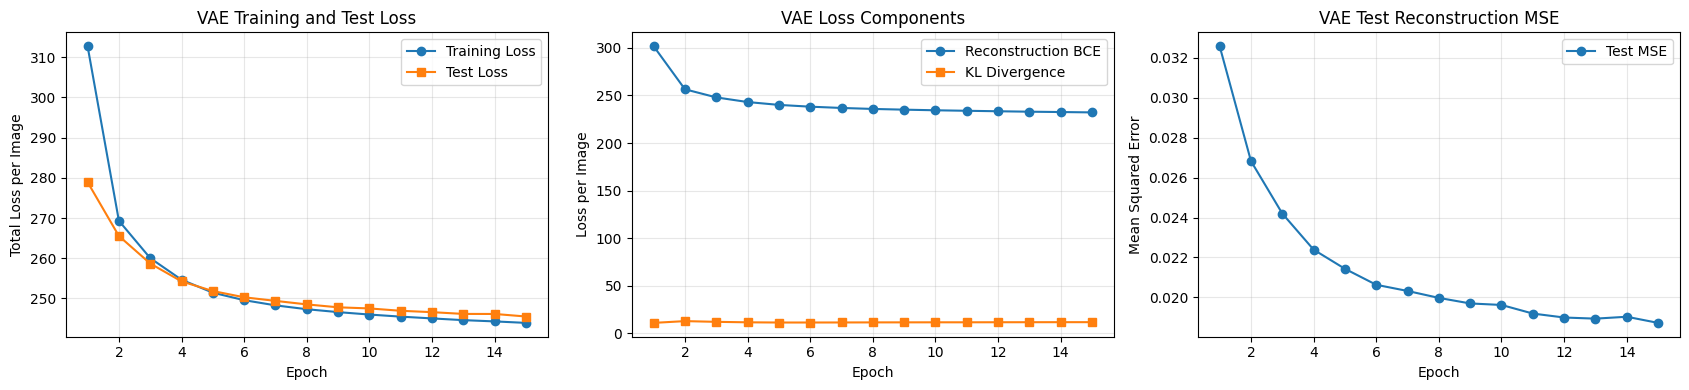

Final VAE Test MSE: 0.018722
FC-AE Test MSE: 0.013123


In [14]:

# Question 2(b): Visualize VAE training results

import matplotlib.pyplot as plt

epochs = range(1, vae_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Graph 1: Training and test total loss
axes[0].plot(
    epochs,
    vae_train_losses,
    marker="o",
    label="Training Loss"
)

axes[0].plot(
    epochs,
    vae_test_losses,
    marker="s",
    label="Test Loss"
)

axes[0].set_title("VAE Training and Test Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total Loss per Image")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2: Reconstruction loss and KL divergence
axes[1].plot(
    epochs,
    vae_train_recon_losses,
    marker="o",
    label="Reconstruction BCE"
)

axes[1].plot(
    epochs,
    vae_train_kl_losses,
    marker="s",
    label="KL Divergence"
)

axes[1].set_title("VAE Loss Components")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss per Image")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Graph 3: Test reconstruction MSE
axes[2].plot(
    epochs,
    vae_test_mse_losses,
    marker="o",
    label="Test MSE"
)

axes[2].set_title("VAE Test Reconstruction MSE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean Squared Error")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final VAE Test MSE:", round(vae_test_mse_losses[-1], 6))
print("FC-AE Test MSE:", round(fc_test_losses[-1], 6))


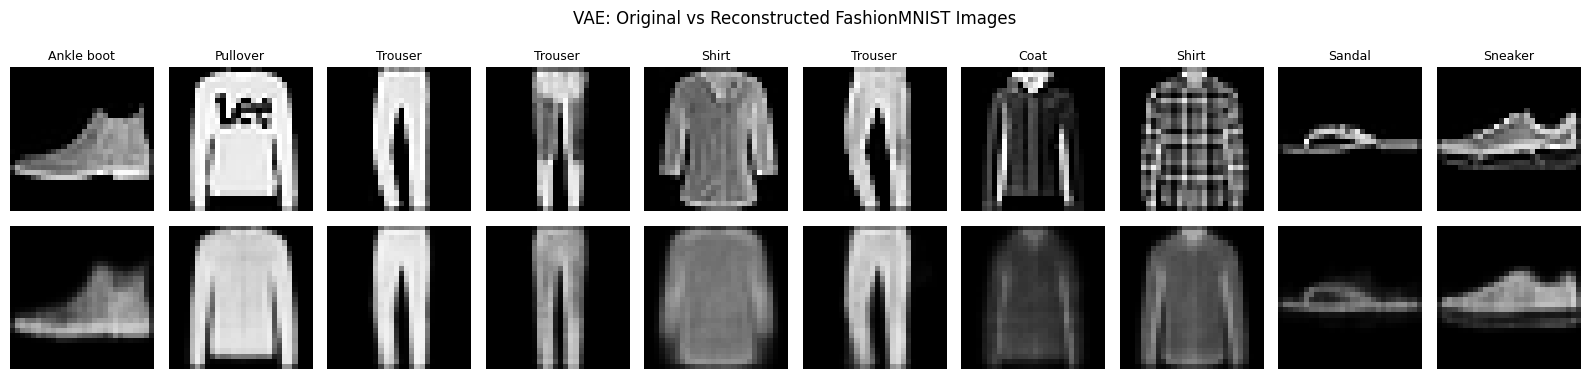

In [15]:

# Question 2(b): Visualize VAE reconstructions

vae.eval()

images, labels = next(iter(test_loader))
images = images[:10].to(device)

with torch.no_grad():
    # Use the latent mean for consistent reconstructions
    encoded = vae.encoder(images)
    mu = vae.fc_mu(encoded)
    reconstructed = vae.decoder(mu)

original_images = images.cpu()
vae_reconstructed_images = reconstructed.cpu()

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for i in range(10):

    # Original image
    axes[0, i].imshow(
        original_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, i].set_title(
        class_names[labels[i].item()],
        fontsize=9
    )
    axes[0, i].axis("off")

    # VAE reconstruction
    axes[1, i].imshow(
        vae_reconstructed_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("VAE", fontsize=11)

plt.suptitle(
    "VAE: Original vs Reconstructed FashionMNIST Images"
)

plt.tight_layout()
plt.show()


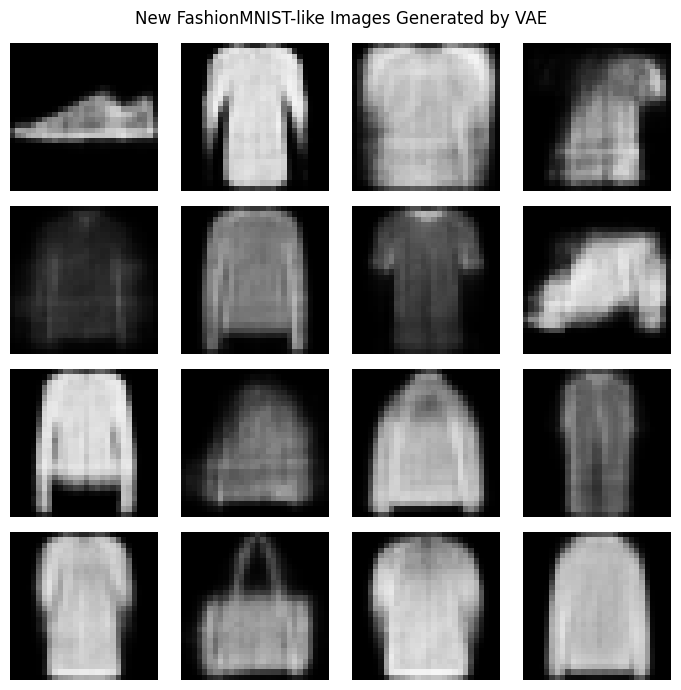

In [16]:

# Question 2(b): Generate new images using VAE

vae.eval()

# Fixed generator for reproducible image generation
sample_generator = torch.Generator(device="cpu")
sample_generator.manual_seed(SEED)

# Sample random latent vectors
z = torch.randn(
    16,
    latent_dim,
    generator=sample_generator
).to(device)

with torch.no_grad():
    generated_images = vae.decoder(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        generated_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    ax.axis("off")

plt.suptitle("New FashionMNIST-like Images Generated by VAE")
plt.tight_layout()
plt.show()



### Question 2(b): VAE Results and Interpretation

**Answer:**

The Variational Autoencoder was trained for 15 epochs using the FashionMNIST dataset. During training, the total loss and reconstruction loss gradually decreased, indicating that the model was learning to reconstruct the input images.

The final test reconstruction MSE using sampled latent vectors was **0.018722**.

For comparison, the Fully Connected Autoencoder achieved a test MSE of **0.013123**. The FC-AE therefore produced a lower reconstruction error in this experiment.

One reason for this difference is that the FC-AE focuses directly on minimizing reconstruction error, while the VAE also uses KL divergence to regularize its latent distribution.

The VAE has an additional advantage: it can generate new clothing-like images by sampling random vectors from its latent space.

Overall, both models learned to reconstruct FashionMNIST images, but they have different objectives. FC-AE focuses on reconstruction accuracy, whereas VAE balances reconstruction and generative modeling.


In [17]:

# Step 19: Generate METRICS.md using actual experiment results

from pathlib import Path
import torch
import torch.nn.functional as F
from datetime import datetime, timezone

# Evaluate both models using deterministic reconstructions
fc_ae.eval()
vae.eval()

fc_sse = 0.0
vae_sse = 0.0
total_pixels = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        # FC-AE reconstruction
        fc_output = fc_ae(images)

        # VAE reconstruction using latent mean
        encoded = vae.encoder(images)
        mu = vae.fc_mu(encoded)
        vae_output = vae.decoder(mu)

        fc_sse += F.mse_loss(
            fc_output, images, reduction="sum"
        ).item()

        vae_sse += F.mse_loss(
            vae_output, images, reduction="sum"
        ).item()

        total_pixels += images.numel()

fc_final_mse = fc_sse / total_pixels
vae_final_mse = vae_sse / total_pixels

# Save comparison metrics
metrics_text = f"""# DATA 266 - Homework 7 Metrics

## Experiment Configuration

| Parameter | Value |
|---|---|
| SID4 | {SID4} |
| Random seed | {SEED} |
| Dataset | FashionMNIST |
| Training images | {len(train_dataset)} |
| Test images | {len(test_dataset)} |
| Framework | PyTorch {torch.__version__} |
| Device | {device} |
| Batch size | {batch_size} |
| Latent dimension | {latent_dim} |
| Epochs | 15 |
| Optimizer | Adam |
| Learning rate | 0.001 |

## Model Comparison

| Metric | FC-AE | VAE |
|---|---:|---:|
| Trainable parameters | {sum(p.numel() for p in fc_ae.parameters() if p.requires_grad)} | {vae_params} |
| Epochs | {fc_epochs} | {vae_epochs} |
| Training objective | MSE | BCE + KL |
| Final training loss | {fc_train_losses[-1]:.6f} | {vae_train_losses[-1]:.6f} |
| Final test loss (training objective) | {fc_test_losses[-1]:.6f} | {vae_test_losses[-1]:.4f} |
| Test reconstruction MSE (deterministic) | {fc_final_mse:.6f} | {vae_final_mse:.6f} |
| Training time (seconds) | {fc_training_time:.2f} | {vae_training_time:.2f} |

## VAE Loss Components

| Metric | Final Value |
|---|---:|
| Reconstruction BCE per image | {vae_train_recon_losses[-1]:.4f} |
| KL divergence per image | {vae_train_kl_losses[-1]:.4f} |
| Sampled test reconstruction MSE | {vae_test_mse_losses[-1]:.6f} |
| Deterministic test reconstruction MSE | {vae_final_mse:.6f} |

## Interpretation

Both models were trained on the same FashionMNIST dataset with
the same batch size, latent dimension, learning rate, and epoch count.

FC-AE directly optimizes reconstruction MSE, while VAE optimizes
reconstruction BCE together with KL divergence.

For a consistent comparison, test reconstruction MSE was calculated
for both models. The VAE was evaluated using its latent mean to
avoid random sampling during final reconstruction evaluation.

The model with lower test MSE has better pixel-level reconstruction
accuracy under this metric. Training time measures the duration
of each model's training and per-epoch evaluation loop.

## Notes

- Test images were not used for gradient updates.
- Training objectives are different and should not be compared directly.
- Pixel values were scaled to [0, 1].
- No additional HP_ID experiment was required for Homework 7.
"""

Path("METRICS.md").write_text(metrics_text, encoding="utf-8")

print(metrics_text)
print("\nSaved METRICS.md successfully!")


# DATA 266 - Homework 7 Metrics

## Experiment Configuration

| Parameter | Value |
|---|---|
| SID4 | 1598 |
| Random seed | 1598 |
| Dataset | FashionMNIST |
| Training images | 60000 |
| Test images | 10000 |
| Framework | PyTorch 2.11.0+cpu |
| Device | cpu |
| Batch size | 128 |
| Latent dimension | 32 |
| Epochs | 15 |
| Optimizer | Adam |
| Learning rate | 0.001 |

## Model Comparison

| Metric | FC-AE | VAE |
|---|---:|---:|
| Trainable parameters | 222384 | 224464 |
| Epochs | 15 | 15 |
| Training objective | MSE | BCE + KL |
| Final training loss | 0.013095 | 243.907375 |
| Final test loss (training objective) | 0.013123 | 245.4949 |
| Test reconstruction MSE (deterministic) | 0.013123 | 0.017353 |
| Training time (seconds) | 191.43 | 208.80 |

## VAE Loss Components

| Metric | Final Value |
|---|---:|
| Reconstruction BCE per image | 232.1943 |
| KL divergence per image | 11.7131 |
| Sampled test reconstruction MSE | 0.018722 |
| Deterministic test reconstruction MSE | 0.01

In [18]:

# Step 20: Generate RUN_LOG.txt from stored experiment results

from pathlib import Path
from datetime import datetime, timezone
import platform

log_lines = []

def add_log(message=""):
    log_lines.append(str(message))

add_log("DATA 266 - Homework 7")
add_log("FC-AE and VAE Training Run Log")
add_log("=" * 65)

add_log(f"Log generated (UTC): {datetime.now(timezone.utc).isoformat()}")
add_log("NOTE: Per-epoch metrics reconstructed from notebook arrays.")
add_log("Original epoch timestamps and uncaptured console errors unavailable.")
add_log("Training durations were recorded during the original runs.")
add_log()

add_log("ENVIRONMENT")
add_log(f"Python: {platform.python_version()}")
add_log(f"PyTorch: {torch.__version__}")
add_log(f"Device: {device}")
if torch.cuda.is_available():
    add_log(f"GPU: {torch.cuda.get_device_name(0)}")
add_log(f"SID4: {SID4}")
add_log(f"SEED: {SEED}")
add_log(f"Training samples: {len(train_dataset)}")
add_log(f"Testing samples: {len(test_dataset)}")
add_log(f"Batch size: {batch_size}")
add_log(f"Latent dimension: {latent_dim}")

add_log()
add_log("=" * 65)
add_log("MODEL 1: FULLY CONNECTED AUTOENCODER")
add_log("=" * 65)

for i, (train_loss, test_loss) in enumerate(
    zip(fc_train_losses, fc_test_losses), start=1
):
    add_log(
        f"Epoch {i:02d}/{fc_epochs} | "
        f"Train MSE: {train_loss:.6f} | "
        f"Test MSE: {test_loss:.6f}"
    )

add_log()
add_log(f"FC-AE training time: {fc_training_time:.2f} seconds")
add_log(f"FC-AE final train MSE: {fc_train_losses[-1]:.6f}")
add_log(f"FC-AE final test MSE: {fc_test_losses[-1]:.6f}")
add_log("FC-AE checkpoint: fc_ae_checkpoint.pt")

add_log()
add_log("=" * 65)
add_log("MODEL 2: VARIATIONAL AUTOENCODER")
add_log("=" * 65)

for i in range(vae_epochs):
    add_log(
        f"Epoch {i + 1:02d}/{vae_epochs} | "
        f"Train Total: {vae_train_losses[i]:.4f} | "
        f"Recon: {vae_train_recon_losses[i]:.4f} | "
        f"KL: {vae_train_kl_losses[i]:.4f} | "
        f"Test MSE: {vae_test_mse_losses[i]:.6f}"
    )

add_log()
add_log(f"VAE training time: {vae_training_time:.2f} seconds")
add_log(f"VAE final total train loss: {vae_train_losses[-1]:.4f}")
add_log(f"VAE final test total loss: {vae_test_losses[-1]:.4f}")
add_log(f"VAE final sampled test MSE: {vae_test_mse_losses[-1]:.6f}")
add_log("VAE checkpoint: vae_checkpoint.pt")

add_log()
add_log("=" * 65)
add_log("FINAL DETERMINISTIC RECONSTRUCTION EVALUATION")
add_log("=" * 65)
add_log(f"FC-AE Test MSE: {fc_final_mse:.6f}")
add_log(f"VAE Test MSE: {vae_final_mse:.6f}")

add_log()
add_log("The original runs completed and saved checkpoints.")
add_log("No claim is made about errors not captured in original logs.")

run_log_text = "\n".join(log_lines) + "\n"

Path("RUN_LOG.txt").write_text(
    run_log_text,
    encoding="utf-8"
)

print(run_log_text)
print("\nRUN_LOG.txt saved successfully!")


DATA 266 - Homework 7
FC-AE and VAE Training Run Log
Log generated (UTC): 2026-10-08T07:00:48.101815+00:00
NOTE: Per-epoch metrics reconstructed from notebook arrays.
Original epoch timestamps and uncaptured console errors unavailable.
Training durations were recorded during the original runs.

ENVIRONMENT
Python: 3.13.16
PyTorch: 2.11.0+cpu
Device: cpu
SID4: 1598
SEED: 1598
Training samples: 60000
Testing samples: 10000
Batch size: 128
Latent dimension: 32

MODEL 1: FULLY CONNECTED AUTOENCODER
Epoch 01/15 | Train MSE: 0.044210 | Test MSE: 0.025872
Epoch 02/15 | Train MSE: 0.023357 | Test MSE: 0.021526
Epoch 03/15 | Train MSE: 0.020151 | Test MSE: 0.019197
Epoch 04/15 | Train MSE: 0.018594 | Test MSE: 0.017994
Epoch 05/15 | Train MSE: 0.017452 | Test MSE: 0.016980
Epoch 06/15 | Train MSE: 0.016583 | Test MSE: 0.016289
Epoch 07/15 | Train MSE: 0.015894 | Test MSE: 0.015679
Epoch 08/15 | Train MSE: 0.015267 | Test MSE: 0.015038
Epoch 09/15 | Train MSE: 0.014779 | Test MSE: 0.014687
Epoch

In [19]:

# Download Homework 7 artifact files

from google.colab import files
from pathlib import Path

required_files = [
    "METRICS.md",
    "RUN_LOG.txt",
    "fc_ae_checkpoint.pt",
    "vae_checkpoint.pt"
]

for filename in required_files:
    if Path(filename).exists():
        print(
            f"Found: {filename} "
            f"({Path(filename).stat().st_size:,} bytes)"
        )
    else:
        print(f"MISSING: {filename}")

# Download metrics and run log
files.download("METRICS.md")
files.download("RUN_LOG.txt")


Found: METRICS.md (1,893 bytes)
Found: RUN_LOG.txt (3,681 bytes)
Found: fc_ae_checkpoint.pt (2,683,961 bytes)
Found: vae_checkpoint.pt (2,711,277 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>